# Experiment: Evaluate an existing yolo from 470 dataset

- Find all models

In [1]:
from pathlib import Path

project_dir = Path("../smart_vine_monitoring")

print(project_dir.resolve())

/Users/willm/Active Projects/precision_agriculture/smart_vine_monitoring


# Import YOLO

In [2]:
from ultralytics import YOLO

print("YOLO imported successfully")

YOLO imported successfully


In [4]:
from pathlib import Path

for f in Path("../smart_vine_monitoring/models").glob("*.pt"):
    print(f)

../smart_vine_monitoring/models/best.pt


In [5]:
from ultralytics import YOLO

model = YOLO("../smart_vine_monitoring/models/best.pt")

print("Loaded successfully")

Loaded successfully


In [6]:
print(model.names)

{0: 'unhealthy_leaf'}


In [8]:
from pathlib import Path

image_paths = []

for ext in ["*.jpg", "*.jpeg", "*.png"]:
    image_paths.extend(Path("../smart_vine_monitoring/frames").rglob(ext))

print(f"Found {len(image_paths)} images")

for p in image_paths[:10]:
    print(p)

Found 12 images
../smart_vine_monitoring/frames/IMG_9869.jpeg
../smart_vine_monitoring/frames/IMG_9865.jpeg
../smart_vine_monitoring/frames/IMG_9864.jpeg
../smart_vine_monitoring/frames/IMG_9868.jpeg
../smart_vine_monitoring/frames/IMG_9863.jpeg
../smart_vine_monitoring/frames/IMG_9859.jpeg
../smart_vine_monitoring/frames/IMG_9862.jpeg
../smart_vine_monitoring/frames/IMG_9861.jpeg
../smart_vine_monitoring/frames/IMG_9860.jpeg
../smart_vine_monitoring/frames/IMG_9867.jpeg


In [10]:
sample = image_paths[0]

results = model(sample, conf=0.25)

print("Detections:", len(results[0].boxes))


image 1/1 /Users/willm/Active Projects/precision_agriculture/notebooks/../smart_vine_monitoring/frames/IMG_9869.jpeg: 1280x736 1 unhealthy_leaf, 560.6ms
Speed: 9.8ms preprocess, 560.6ms inference, 5.9ms postprocess per image at shape (1, 3, 1280, 736)
Detections: 1


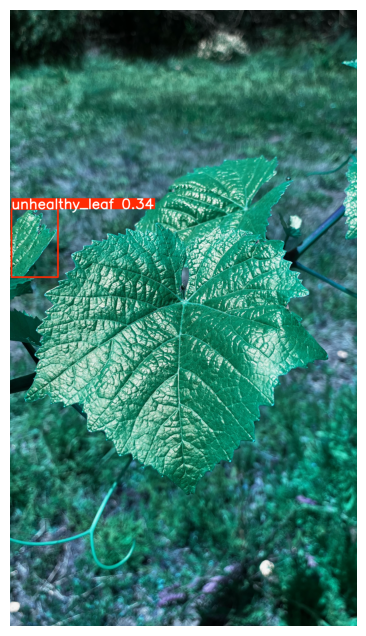

In [12]:
from matplotlib import pyplot as plt

annotated = results[0].plot()

plt.figure(figsize=(14,8))
plt.imshow(annotated)
plt.axis("off")
plt.show()

In [13]:
results = model(sample, conf=0.50)


image 1/1 /Users/willm/Active Projects/precision_agriculture/notebooks/../smart_vine_monitoring/frames/IMG_9869.jpeg: 1280x736 (no detections), 541.9ms
Speed: 7.2ms preprocess, 541.9ms inference, 0.4ms postprocess per image at shape (1, 3, 1280, 736)


## Initial Finding

The inherited `unhealthy_leaf` YOLO model loaded successfully and produced one detection on IMG_9869.jpeg at confidence 0.25.

However, the detected box appeared to be a false positive, and when the confidence threshold was raised to 0.50, the model produced no detections.

This suggests the existing model may not be reliable enough, by itself, to generate anomaly regions.